# Mini-Project: [Your Title Here]
**Intern:** Jeong WooJin
**Date started:** 26.08.17.


---
## Context

You have already worked with this dataset in Module 4:

- **Data:** Fur ChIP-exo binding sites from Seo et al. 2014 — *Nature Communications* 5:4910 (GEO series **GSE54901** for the raw signal; the discrete binding sites come from the paper's **Supplementary Data** table you downloaded in Module 4)
- **Organism:** *E. coli* K-12 MG1655
- **Files in `data/reference/`:** Fur binding-site table (iron-replete sites, with `ChIP-exo Start`/`End`, `S/N ratio`, `Significance`, `Distance to TSS`), `NC_000913.fasta`, `ec_annotation_20100903_DHK_cSRNA_with_ortho.gff`, and the `fur_sites_for_meme.fasta` you generated.

Module 4 asked one specific question: *find the FUR binding motif.* This project asks you to go further and answer a question of your own choosing about the FUR regulon.


---
## Schedule Overview

| Day | Target milestone |
|-----|------------------|
| W5 D1 | Literature review done; candidate questions drafted |
| W5 D2 | Biological question finalized and instructor-approved |
| W5 D3 | Analysis plan written; pipeline scaffold annotated |
| W5 D4–5 | Pipeline running; first results visible |
| W6 D1–3 | All steps done; figures generated |
| W6 D4–5 | Report written; notebook submitted |

Run `/log` at the end of **every day**.


---
## Part 1 — What Else Is Known About FUR?
**Target: W5 Day 1**

You already know the Seo et al. 2014 dataset. Before proposing a question, find out what other groups have studied about the FUR regulon in *E. coli* — you want to ask something that either extends, challenges, or fills a gap in the existing literature.

Use Claude to help search and summarize. Key questions to answer:
- What genes are in the known FUR regulon?
- What is already known about FUR binding site position relative to promoters/TSS?
- Are there known differences between iron-replete and iron-depleted conditions?
- What aspects of FUR binding have *not* been studied with ChIP-exo?


**Literature summary** — 4–6 sentences covering what is known and what gaps exist:


> **Answer**
>
> Fur가 직접 조절하는 유전자는 Seo et al. 2014 기준 direct regulon 81개(HR 65개, HA 12개, AA 4개)이며, 최근 Gao et al. 2023(NAR)은 9개 균주의 ChIP-exo/RNA-seq를 통합해 469개 유전자로 구성된 pan-regulon을 core(36개)/accessory(158개)/unique(275개)로 확장했다. Fur box는 19bp palindromic 서열로 보통 promoter의 −35~−10 영역 사이에 위치하며, Escolar et al. 1998에 따르면 한 부위에 Fur box가 여러 개 tandem으로 있을 때 첫 번째 자리의 결합 친화도가 가장 높고 뒤따르는 자리는 상대적으로 약하다고 알려져 있다. 철이 충분한 조건(iron-replete)에서는 Fe2+가 결합한 holo-Fur가 DNA에 강하게 결합해 전사를 억제하고, 철이 부족한 조건(iron-depleted)에서는 apo-Fur가 DNA 친화성을 잃고 이탈하면서 억제가 풀린다는 것이 잘 정립되어 있다. 그러나 Gao et al. 2023은 Fur 결합 peak이 promoter가 있는 유전자간(intergenic) 영역뿐 아니라 유전자 내부(intragenic) 영역에서도 비슷한 빈도로 발견되며, 그중 일부만 실제 promoter 영역과 겹친다는 점을 보고했는데, 이 intragenic/non-promoter 결합부위들이 기능적으로 무엇을 하는지는 아직 체계적으로 설명되지 않았다. 본 데이터셋(Seo et al. 2014)에도 Location 컬럼에 regulatory(80개)뿐 아니라 Internal(57개), downstream(7개) 부위가 상당수 존재해, 이 gap을 직접 데이터로 확인해볼 수 있는 여지가 있다.


*참고문헌 목록*
1. Seo, Sang Woo, et al. "Deciphering Fur transcriptional regulatory network highlights its complex role beyond iron metabolism in Escherichia coli." Nature communications 5.1 (2014): 4910.

2. Gao, Ye, et al. "The Escherichia coli Fur pan-regulon has few conserved but many unique regulatory targets." Nucleic Acids Research 51.8 (2023): 3618-3630.

3. Escolar, Lucı́a, José Pérez-Martı́n, and Vı́ctor de Lorenzo. "Binding of the fur (ferric uptake regulator) repressor of Escherichia coli to arrays of the GATAAT sequence." Journal of molecular biology 283.3 (1998): 537-547.

4. Shultzaberger, Ryan K., et al. "Anatomy of Escherichia coli σ 70 promoters." Nucleic acids research 35.3 (2007): 771-788.

> **W5 D1 checkpoint:**
> - [ ] At least 2 papers read beyond Seo et al. 2014
> - [ ] Gap or open question identified
> - [ ] `/log` run


---
## What Makes a Good Biological Question?

Before writing your question, use this checklist:

| Criterion | Ask yourself |
|-----------|-------------|
| **Answerable with available data** | Can you answer it using the files already in `data/reference/`? |
| **Not already answered** | Did Seo et al. 2014 or the papers you just read already answer this? |
| **Has a plausible mechanism** | If you found a pattern, would there be a biological reason for it? |
| **Specific and testable** | Can you describe the analysis in 2–3 steps and know what result would count as a "yes" or "no"? |

> **What the binding-site table gives you:** each Fur site has a `ChIP-exo Start`/`End`, a **`S/N ratio`** and a **`Significance (p-value)`** (these are the *signal-strength* / *score* fields — the `Peak` column is just an ID label like `P1`), a `Binding Condition` (`R` iron-replete / `S` iron-depleted / `R/S` both), and a `Distance to TSS` for many sites. Design your question around columns that actually exist.

### Examples of tractable questions with the FUR dataset

- *Do FUR binding sites closer to a TSS have a higher S/N ratio than sites far from a TSS?*
- *Are FUR sites that bind in both conditions (`R/S`) stronger (higher S/N ratio) than condition-specific ones?*
- *Does the GC content of FUR binding site sequences correlate with the site's S/N ratio?*
- *Which functional categories (metabolism, transport, stress response) of the target genes are most enriched among FUR binding sites?*

### Examples of questions to avoid

- *"What does FUR do?"* — already answered in the literature
- *"How many peaks are there?"* — answered in Module 4
- *"Is FUR important for iron regulation?"* — too broad, not answerable with this dataset alone

### Where to search for background

- **PubMed:** `pubmed.ncbi.nlm.nih.gov` — search `"FUR regulon E. coli"` or `"Fur binding E. coli iron"`
- **Google Scholar:** same search terms
- **The Seo et al. 2014 paper itself** — its Discussion section lists open questions

---


In [5]:
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리
from scipy.stats import kruskal  # 3개 이상 그룹 사이에 분포 차이가 있는지 검정하는 통계 함수

# ----- 1단계: 원본 엑셀 데이터 불러오기 -----
fur = pd.read_excel(
    "../data/reference/ncomms5910_SupplementaryData1_Fur_ChIPexo_binding_sites.xlsx",
    sheet_name=0,
    header=1
)

# ----- 2단계: Significance 컬럼에 섞여있는 '-' 문자를 결측치(NaN)로 바꾸고 숫자형으로 변환 -----
# pd.to_numeric(..., errors="coerce"): 숫자로 안 바뀌는 값('-' 같은 것)은 에러 대신 NaN으로 처리
fur["Significance_numeric"] = pd.to_numeric(
    fur["Significance (p-value) of similarity to Fur box"],
    errors="coerce"
)

# ===== 검정 1: Location별 S/N ratio(결합 신호 세기) 차이 =====
print("===== 검정 1: Location별 S/N ratio =====")
print(fur.groupby("Location")["S/N ratio"].agg(["count", "median", "mean"]))

sn_groups = [
    group["S/N ratio"].dropna().values  # 결측치 제거 후 값만 추출
    for name, group in fur.groupby("Location")  # Location(regulatory/Internal/downstream)별로 그룹화
]
stat_sn, pvalue_sn = kruskal(*sn_groups)  # Kruskal-Wallis 검정 실행
print(f"S/N ratio 차이: statistic={stat_sn:.3f}, p-value={pvalue_sn:.4g}")

# ===== 검정 2: Location별 Fur box 서열 유사도(Significance) 차이 =====
print("\n===== 검정 2: Location별 Fur box 서열 유사도 =====")
print(fur.groupby("Location")["Significance_numeric"].agg(["count", "median", "mean"]))

sig_groups = [
    group["Significance_numeric"].dropna().values  # 결측치 제거 후 값만 추출
    for name, group in fur.groupby("Location")
]
stat_sig, pvalue_sig = kruskal(*sig_groups)  # Kruskal-Wallis 검정 실행
print(f"Significance 차이: statistic={stat_sig:.3f}, p-value={pvalue_sig:.4g}")

===== 검정 1: Location별 S/N ratio =====
            count  median       mean
Location                            
Internal       57    2.90   3.714386
downstream      7    3.47   8.562857
regulatory     80   20.70  50.407500
S/N ratio 차이: statistic=41.849, p-value=8.177e-10

===== 검정 2: Location별 Fur box 서열 유사도 =====
            count  median       mean
Location                            
Internal       57  19.000  31.993906
downstream      7  43.000  61.778571
regulatory     79   0.025  13.856980
Significance 차이: statistic=35.330, p-value=2.129e-08


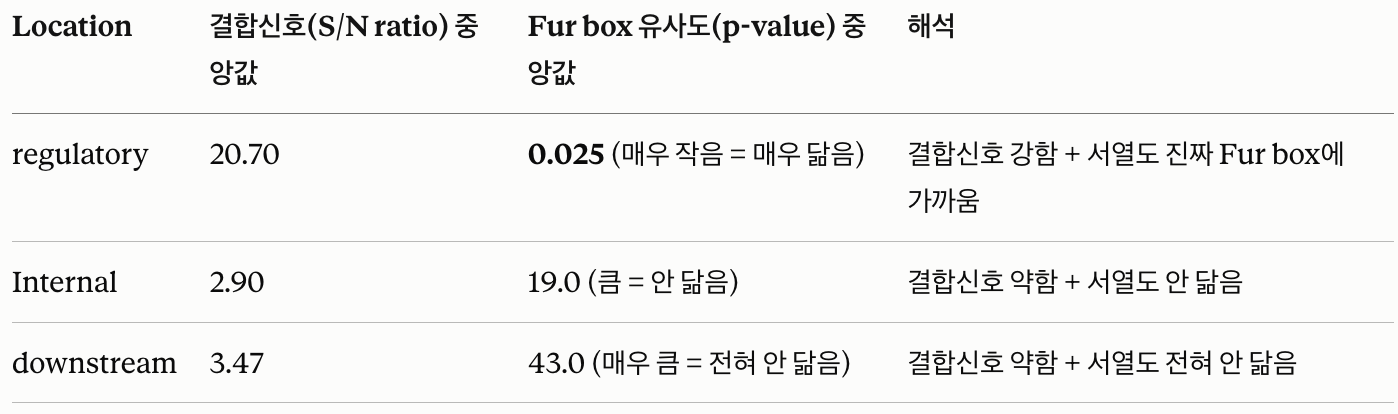

---
## Part 2 — Biological Question
**Target: W5 Day 2**

Propose **one specific, answerable** question about the FUR ChIP-exo dataset that goes beyond what Module 4 already showed you.

The question must be answerable using the files in `data/reference/`. If you need additional tools or datasets, use Claude Code to set them up.

Example questions at the right level of specificity:
- *"Do FUR binding sites with a higher S/N ratio show stronger motif matches than low-signal sites?"*
- *"Which genes in the lab annotation have a FUR binding site within their upstream region, and can you find a pattern in what those genes do?"*
- *"Do iron-replete–specific FUR sites (`R`) differ in location (regulatory vs internal) from sites bound in both conditions (`R/S`)?"*
- *"How does the GC content of FUR binding site sequences compare to randomly sampled genomic windows of the same length — and does GC content correlate with S/N ratio?"*

**Not acceptable:** *"What does FUR do?"* or *"How many peaks are there?"* (already answered in M4)


**My biological question:**


> **Answer**
>
> **1. 가설**: 
>   Fur ChIP-exo 결합 부위 중 promoter 근처(regulatory)가 아닌 부위(Internal, downstream)는 결합 신호(S/N ratio)와 Fur box 서열 유사도(motif p-value)가 regulatory 부위보다 일관되게 약할 것이다.
>
> H0 (귀무): Location(regulatory / Internal / downstream) 그룹 간 S/N ratio와 motif p-value 분포에 차이가 없다.
> H1 (대립): Location 그룹 간 두 지표 모두에서 유의미한 차이가 있으며, 특히 regulatory가 아닌 그룹에서 두 지표가 함께 약하게 나타난다.
>
> **2. 가설 설정 배경**: Module 4에서 fhuA를 binding + motif + expression 세 층위 증거로 검증했을 때, 세 증거가 일치할수록 신뢰도가 높다는 원칙을 세웠다. 이번에는 그 논리를 반대 방향으로 적용해, 서로 독립적인 두 증거(결합 신호 세기, 서열 유사도)가 동시에 약한 부위는 기능적 결합이 아닌 배경 노이즈일 가능성이 있다고 보고 검증하고자 한다. Gao et al. 2023(NAR)은 Fur 결합 peak이 promoter가 아닌 유전자 내부(intragenic) 영역에서도 비슷한 빈도로 발견된다고 보고했으나, 이 부위들이 기능적으로 의미가 있는지는 다루지 않았다 — 본 질문은 이 gap을 직접 데이터로 확인하는 것이다.
>
> **3. 사용할 DB**: ncomms5910_SupplementaryData1_Fur_ChIPexo_binding_sites.xlsx의 Location, S/N ratio, Significance (p-value) of similarity to Fur box 컬럼 (총 145개 결합부위, Location별 regulatory 80 / Internal 57 / downstream 7 / Not a Number 1).
>
> **4. 예비 확인 결과**: Location별 S/N ratio 차이는 Kruskal-Wallis 검정 결과 유의미했다(p=8.18e-10, regulatory 중앙값 20.70 vs Internal 2.90 vs downstream 3.47). Significance(서열 유사도 p-value) 역시 Location별로 유의미하게 달랐다(p=2.13e-08, regulatory 중앙값 0.025 vs Internal 19.0 vs downstream 43.0 — 값이 작을수록 Fur box와 유사함을 의미). 두 지표 모두 같은 방향(regulatory가 강하고 유사함)으로 나타나, 본 가설을 뒷받침하는 예비 신호를 확인했다.
>
> **5. 판단 기준**: 두 지표 모두에서 p<0.05이고 regulatory와 non-regulatory 그룹 간 중앙값 차이의 방향이 일치하면(강한 신호=regulatory, 약한 신호=non-regulatory), Internal/downstream 부위가 기능적 Fur 결합일 가능성이 상대적으로 낮다는 해석을 뒷받침한다고 판단한다.


> **INSTRUCTOR CHECK-IN REQUIRED** before proceeding to Part 3.  
> Do not start the analysis plan until your question is approved.


---
## Part 3 — Analysis Plan
**Target: W5 Day 3**

Write your analysis plan **before** opening Claude Code. This is your own thinking.

Your plan must answer:
1. Which files in `data/reference/` will you use?
2. What steps will you run, in order?
3. What output do you expect at each step?
4. How will you decide if the result is biologically meaningful?


> **Answer**
>
> [Your analysis plan here — write this before asking Claude Code]


**Pipeline scaffold** — use plan mode (Shift+Tab twice) to generate the pipeline.  
Review every proposed step. Annotate each command with your own understanding of what it does.


In [ ]:
# Pipeline scaffold — generated with plan mode, annotated by you.
# If any cell holds shell commands (bowtie2, samtools, fastq-dump, meme...),
# make its FIRST line %%bash — otherwise Jupyter runs them as Python and errors.
# Pure-Python analysis cells (pandas, Biopython, matplotlib) need no magic.



> **W5 D3 checkpoint:**
> - [ ] Analysis plan written in your own words
> - [ ] Pipeline scaffold annotated (you can explain every command)
> - [ ] Instructor has approved your biological question
> - [ ] `/log` run


---
## Part 4 — Analysis Execution
**Target: W5 Days 4–5 and W6 Days 1–3**

Run your pipeline step by step. Add code cells as needed.  
When blocked: paste the error + command + relevant output into Claude Code and ask for diagnosis — then use `/debug`.

Track your progress:

| Step | Status |
|------|--------|
| [Step 1 name] | not started / in progress / done |
| [Step 2 name] | not started / in progress / done |
| [Step 3 name] | not started / in progress / done |



In [ ]:
# Step 1


> **Answer**
>
> *What did this step produce? Any issues?*


In [ ]:
# Step 2


> **Answer**
>
> *What did this step produce? Any issues?*


In [ ]:
# Step 3


> **Answer**
>
> *What did this step produce? Any issues?*


*(Add more step cells as needed.)*


> **W5 D5 checkpoint:**
> - [ ] At least first 2 steps producing output
> - [ ] Any blockers documented in `/log`
> - [ ] `/log` run


---
## Part 5 — Results
**Target: W6 Days 1–3**

Document your results. Each figure needs a 1–2 sentence caption — what it shows and what you observe.


In [ ]:
# Figure 1


> **Answer**
>
> **Figure 1:** [What this figure shows and what you observe]


In [ ]:
# Figure 2 (add as needed)


> **Answer**
>
> **Figure 2:** [Caption]


> **W6 D3 checkpoint:**
> - [ ] All pipeline steps complete
> - [ ] At least one figure with a written caption
> - [ ] `/log` run


---
## Part 6 — Report
**Target: W6 Days 4–5**

Write your report in the cells below. This is **your own writing** — Claude may be consulted for phrasing, but the scientific content must be yours.


### Question
*(one sentence)*


> **Answer**
>
> [Your question here]


### Methods
*(tools, parameters, files used — enough to reproduce)*


> **Answer**
>
> [Your methods here]


### Results
*(what did you find? reference figures by number)*


> **Answer**
>
> [Your results here]


### Interpretation
*(what does this mean biologically? how does it compare to the known FUR regulon?)*


> **Answer**
>
> [Your interpretation here]


### Limitations
*(what would you do differently with more time?)*


> **Answer**
>
> [Your limitations here]


---
Run `/log` one last time, then submit this notebook as your deliverable.


## Git — Commit Your Work

Every session ends with a commit. Run the commands below in your terminal (not in this notebook).

Write your own commit message following the format: `feat(miniproject): <what you did>`.  
If you're unsure what to write, ask Claude Code to suggest one based on what you worked on.

In [ ]:
# Run these in the terminal (not here):
# git add notebooks/
# git commit -m "..."   # write your own commit message; use Claude Code to help if needed
# git push
